# Shapley Methods — Results Analysis

Reusable analysis notebook. Change `DATASET` in the **Configuration** cell and re-run all cells to analyse any experiment run.

Sections:
1. Configuration & Imports
2. Pipeline Timing Summary
3. Load Shapley Values
4. Compute All Metrics (Centralized)
5. Instance-Level Configuration
6. Causal Graph Structure: PC vs LiNGAM
   - 6.1. True Causal Graph
7. Causal Neighbourhood: PC | True | LiNGAM *(focused ego-network — all three graphs)*
   - 7.1. SHAP Attribution Comparison: PC vs LiNGAM
8. True DAG Node Highlight *(merged into Section 7)*
9. Graph Sensitivity Analysis
   - 9.1. Data Check
   - 9.2. Graph Sensitivity Score (GSS)
   - 9.3. Ranking Robustness & True-Parent Recovery
   - 9.4. Sign Stability Score (SSS)
   - 9.5. Method Recommendation Summary
10. True-Graph Alignment (TGA)
    - 10.1. Sign Alignment vs True Graph
    - 10.2. Magnitude True-Graph Alignment
    - 10.3. Sign Alignment vs Traditional Baseline
    - 10.4. Magnitude TGA vs Traditional Baseline
11. Feature Importance Export
12. Adjacency Matrix Comparison
13. Node-Level Accuracy


## 1. Configuration & Imports

In [25]:
import sys
from pathlib import Path as _Path
sys.path.insert(0, str(_Path("..").resolve()))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import json, re
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import importlib
import analysis_utils
importlib.reload(analysis_utils)

from analysis_utils import (
    resolve_features,
    mean_abs_shap,
    compute_sign_alignment, compute_tga, compute_sss, compute_gss,
    edge_recovery, flow_graph_stats, parse_pipeline_timing,
    build_dag_graph, make_dag_pos, draw_dag, draw_dag_highlight, PROX_PALETTE,
    plot_shap_scatter_pc_vs_lingam, plot_instance_shap_pc_vs_lingam,
    plot_timing_table,
    plot_feature_importance_bar,
    plot_dag_comparison,
    plot_true_dag, plot_dag_highlight, plot_dag_highlight_true,
    plot_node_neighborhood,
    plot_gss_heatmap, plot_gss_delta_box,
    plot_sss_heatmap, plot_sss_bar,
    plot_sign_alignment_heatmap, plot_sign_alignment_bar,
    plot_tga_heatmap, plot_tga_bar,
    plot_adjacency_comparison,
    compute_node_accuracy, get_node_accuracy,
    plot_shap_vs_feature, plot_shap_vs_instance
)


In [2]:
import kaleido, importlib
print(dir(kaleido))
print(kaleido.__file__)
# Check what plotly actually looks for
import plotly.io._kaleido as pk
import inspect
print(inspect.getsource(pk))


['Kaleido', 'PageGenerator', 'TYPE_CHECKING', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_global_server', '_kaleido_tab', '_page_generator', '_profiler', '_sync_server', '_utils', 'annotations', 'calc_fig', 'calc_fig_sync', 'get_chrome', 'get_chrome_sync', 'kaleido', 'start_sync_server', 'stop_sync_server', 'write_fig', 'write_fig_from_object', 'write_fig_from_object_sync', 'write_fig_sync']
/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/kaleido/__init__.py
import os
import json
from pathlib import Path
from typing import Union, List
import importlib.metadata as importlib_metadata
from packaging.version import Version
import warnings

import plotly
from plotly.io._utils import validate_coerce_fig_to_dict, broadcast_args_to_dicts
from plotly.io._defaults import defaults

ENGINE_SUPPORT_TIMELINE = "September 2025"
ENABLE_KALEIDO_V0_DEPRECATION_WARNINGS = True

PLOTLY_GET_CHR

In [3]:
# ── Change these two lines to re-run analysis on any dataset ───────────
DATASET        = "linear_conf_f50_s1000_p30"

MODEL          = "lgbm"

# Number of top features (ranked by ShapleyFromScratch) shown in
# the bar chart (Analysis 4) and scatter grid (Analyses 5 & 6).
N_TOP_FEATURES = 20

# ── Paths (notebook lives in notebooks/, project root is one level up) ──
BASE_DIR           = Path("..").resolve()
EXPLAINABILITY_DIR = BASE_DIR / "data" / "explainability"
CAUSAL_DIR         = BASE_DIR / "data" / "causal"
PROCESSED_DIR      = BASE_DIR / "data" / "processed"
SYNTHETIC_DIR      = BASE_DIR / "data" / "synthetic"
LOGS_DIR           = BASE_DIR / "logs"

# ── Plots output directory ───────────────────────────────────────────────
PLOTS_DIR = Path("plots") / DATASET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Method lists ─────────────────────────────────────────────────────────
BASE_METHODS = ["Asymmetric", "Causal", "Flow"]
DISC_GRAPHS  = ["PC", "LiNGAM"]

# ── Consistent colour scheme across all plots ───────────────────────────
METHOD_COLORS = {
    "Scratch":     "#636363",
    "Asymmetric":  "#2166ac",
    "Causal":      "#4dac26",
    "ShapleyFlow": "#d01c8b",
}

print(f"Dataset : {DATASET}")
print(f"Model   : {MODEL}")
print(f"Top N   : {N_TOP_FEATURES}")
print(f"Plots   : {PLOTS_DIR}")
print(f"Synthetic dir exists: {SYNTHETIC_DIR.exists()}")


Dataset : linear_conf_f50_s1000_p30
Model   : lgbm
Top N   : 20
Plots   : plots/linear_conf_f50_s1000_p30
Synthetic dir exists: True


## 2. Pipeline Timing Summary

In [4]:
timing_df, total_time = parse_pipeline_timing(LOGS_DIR, DATASET)
if timing_df is not None:
    fig_timing = plot_timing_table(timing_df, total_time, DATASET, save_dir=PLOTS_DIR)
else:
    print("Could not parse timing log.")


Log file: pipeline_20260601_012626.log


  ✅  Saved → plots/linear_conf_f50_s1000_p30/timing_table_linear_conf_f50_s1000_p30.png


## 3. Load Shapley Values

In [5]:
exp_dir = EXPLAINABILITY_DIR / DATASET / MODEL

# ── Method registry ───────────────────────────────────────────────────────
# key  : display name used across all plots
# value: relative path inside exp_dir
METHOD_PATHS = {
    "Scratch":                exp_dir / "scratch"  / "shapley_values.npy",
    "Asymmetric (PC)":        exp_dir / "pc"       / "asymmetric" / "shapley_values.npy",
    "Causal (PC)":            exp_dir / "pc"       / "causal"     / "shapley_values.npy",
    "Flow (PC)":              exp_dir / "pc"       / "flow"       / "shapley_values.npy",
    "Asymmetric (LiNGAM)":   exp_dir / "lingam"   / "asymmetric" / "shapley_values.npy",
    "Causal (LiNGAM)":       exp_dir / "lingam"   / "causal"     / "shapley_values.npy",
    "Flow (LiNGAM)":         exp_dir / "lingam"   / "flow"       / "shapley_values.npy",
    "Asymmetric (True)":     exp_dir / "true" / "asymmetric" / "shapley_values.npy",
    "Causal (True)":            exp_dir / "true" / "causal"     / "shapley_values.npy",
    "Flow (True)":       exp_dir / "true" / "flow"       / "shapley_values.npy",
}

shap_data = {}
for name, path in METHOD_PATHS.items():
    if path.exists():
        sv = np.load(path)
        shap_data[name] = sv
        nan_pct = 100 * np.isnan(sv).mean()
        zero_pct = 100 * (sv == 0).mean()
        print(f"  {name:28s}  shape={sv.shape}  "
              f"mean|SHAP|={np.abs(sv).mean():.4f}  "
              f"NaN={nan_pct:.1f}%  zeros={zero_pct:.1f}%")
    else:
        print(f"  {name:28s}  NOT FOUND: {path}")

# ── Feature names (X only, no Y) ─────────────────────────────────────────
with open(CAUSAL_DIR / f"{DATASET}_pc_results.json") as f:
    pc_results = json.load(f)
with open(CAUSAL_DIR / f"{DATASET}_lingam_results.json") as f:
    lingam_results = json.load(f)

feature_names = [n for n in pc_results["feature_names"] if n != "Y"]
n_features    = len(feature_names)

# ── Test instances used for SHAP (first n_shap rows of test set) ──────────
n_shap   = shap_data["Scratch"].shape[0]
test_df  = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
x_test   = test_df[feature_names].iloc[:n_shap].values   # shape: (n_shap, n_features)

# ── Graph statistics ──────────────────────────────────────────────────────
pc_edges,     pc_sources     = flow_graph_stats(pc_results["adjacency_matrix"],     n_features)
lingam_edges, lingam_sources = flow_graph_stats(lingam_results["adjacency_matrix"], n_features)

print(f"\nFeatures : {n_features}    SHAP instances : {n_shap}")
print(f"PC graph     : {pc_edges} edges, {pc_sources} sources")
print(f"LiNGAM graph : {lingam_edges} edges, {lingam_sources} sources")

# ── Adjacency matrices ────────────────────────────────────────────────────
pc_adj       = np.array(pc_results["adjacency_matrix"])
pc_names     = pc_results["feature_names"]
lingam_adj   = np.array(lingam_results["adjacency_matrix"])
lingam_names = lingam_results["feature_names"]
true_adj     = np.load(CAUSAL_DIR / f"{DATASET}_true_full_adjacency.npy")
true_names   = pc_names  # same feature ordering (X0…X{n-1}, Y)

# X-only (n×n) adjacency blocks for graph-comparison metrics
true_adj_xx         = true_adj[:n_features, :n_features]
pc_train_adj_xx     = np.load(CAUSAL_DIR / f"{DATASET}_pc_train_adjacency.npy")
lingam_train_adj_xx = np.load(CAUSAL_DIR / f"{DATASET}_lingam_train_adjacency.npy")

# ── Non-Scratch SHAP subset (used by alignment and TGA metrics) ───────────
subset_shap_data = {k: v for k, v in shap_data.items() if k != "Scratch"}
N_TRUE_INSTANCES = list(subset_shap_data.values())[0].shape[0]

# ── Model prediction std (normalises TGA and GSS) ────────────────────────
import joblib as _joblib
_output_std = None
_model_path = BASE_DIR / "models" / f"{DATASET}_{MODEL}.pkl"
if _model_path.exists():
    _model_data = _joblib.load(_model_path)
    _lgbm       = _model_data["model"]
    _sel_feat   = _model_data.get("selected_features")
    _df_test    = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
    _X          = _df_test.drop(columns=["Y"], errors="ignore")
    if _sel_feat is not None:
        _X = _X[_sel_feat]
    _preds = _lgbm.predict(_X)
    _output_std = float(_preds.std())
    print(f"Model prediction std: {_output_std:.4f}")
else:
    print("⚠️  Model not found — TGA and GSS will not be normalised")

# ── Aliases for downstream cells ──────────────────────────────────────────
feat_names_10 = feature_names   # alias kept for backward-compat with sections 9–13


  Scratch                       shape=(100, 50)  mean|SHAP|=0.2319  NaN=0.0%  zeros=0.0%
  Asymmetric (PC)               shape=(100, 50)  mean|SHAP|=0.2324  NaN=0.0%  zeros=0.0%
  Causal (PC)                   shape=(100, 50)  mean|SHAP|=0.3130  NaN=0.0%  zeros=0.0%
  Flow (PC)                     shape=(100, 50)  mean|SHAP|=0.2722  NaN=0.0%  zeros=11.1%
  Asymmetric (LiNGAM)           shape=(100, 50)  mean|SHAP|=0.2329  NaN=0.0%  zeros=0.2%
  Causal (LiNGAM)               shape=(100, 50)  mean|SHAP|=0.3061  NaN=0.0%  zeros=0.0%
  Flow (LiNGAM)                 shape=(100, 50)  mean|SHAP|=0.2609  NaN=0.0%  zeros=9.4%
  Asymmetric (True)             shape=(100, 50)  mean|SHAP|=0.2321  NaN=0.0%  zeros=0.0%
  Causal (True)                 shape=(100, 50)  mean|SHAP|=0.3348  NaN=0.0%  zeros=0.0%
  Flow (True)                   shape=(100, 50)  mean|SHAP|=0.2379  NaN=0.0%  zeros=7.5%

Features : 50    SHAP instances : 100
PC graph     : 104 edges, 18 sources
LiNGAM graph : 155 edges, 14 sour

## 4. Compute All Metrics (Centralized)

Compute all metrics once using standard functions from `analysis_utils.py`:
- **GSS** (Graph Sensitivity Score) — PC vs LiNGAM magnitude bias
- **SSS** (Sign Stability Score) — PC vs LiNGAM sign agreement
- **Sign Alignment vs True** — fraction where sign matches True graph
- **TGA vs True** — magnitude deviation from True graph
- **Sign Alignment vs Scratch** — fraction where sign matches Traditional baseline
- **TGA vs Scratch** — magnitude deviation from Traditional baseline

All visualizations and summaries later in the notebook use these pre-computed variables.

In [6]:
# ── GSS: Graph Sensitivity Score (PC vs LiNGAM magnitude bias) ────────────────
# Returns per-feature arrays: dict[method] -> ndarray(n_features,)
gss_feat = compute_gss(shap_data, BASE_METHODS, output_std=_output_std)

# Per-instance deltas (un-averaged) for box plots
feat_delta = {
    meth: np.abs(shap_data[f"{meth} (PC)"]) - np.abs(shap_data[f"{meth} (LiNGAM)"])
    for meth in BASE_METHODS
    if f"{meth} (PC)" in shap_data and f"{meth} (LiNGAM)" in shap_data
}

# ── SSS: Sign Stability Score (PC vs LiNGAM sign agreement) ───────────────────
# Returns per-feature arrays: dict[method] -> ndarray(n_features,)
sss_feat = compute_sss(shap_data, BASE_METHODS)

# ── Sign Alignment vs True DAG ─────────────────────────────────────────────────
# Returns per-feature arrays: dict[(method, graph)] -> ndarray(n_features,)
DISC_GRAPHS_TGA = ["PC", "LiNGAM"]

sign_align = compute_sign_alignment(subset_shap_data, BASE_METHODS, DISC_GRAPHS_TGA, reference="True")

# ── Magnitude TGA vs True DAG ──────────────────────────────────────────────────
# Returns per-feature arrays: dict[(method, graph)] -> ndarray(n_features,)
tga_data, zero_feat_sets = compute_tga(
    subset_shap_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA,
    reference="True", output_std=_output_std,
)

# ── Sign Alignment vs Scratch (Traditional baseline) ──────────────────────────
combined_scratch = dict(subset_shap_data)
if "Scratch" in shap_data:
    combined_scratch["Scratch"] = shap_data["Scratch"]

DISC_GRAPHS_SCRATCH = ["PC", "LiNGAM"]

sign_align_scratch = compute_sign_alignment(
    combined_scratch, BASE_METHODS, DISC_GRAPHS_SCRATCH, reference="Scratch"
)

# ── Magnitude TGA vs Scratch (Traditional baseline) ───────────────────────────
tga_data_scratch, zero_feat_sets_scratch = compute_tga(
    combined_scratch, feature_names, BASE_METHODS, DISC_GRAPHS_SCRATCH,
    reference="Scratch", output_std=_output_std,
)

# ── Mean absolute SHAP per feature ────────────────────────────────────────────
mean_abs = {name: np.abs(sv).mean(axis=0) for name, sv in shap_data.items()}

# All features ranked by Scratch importance
scratch_rank = np.argsort(mean_abs['Scratch'])[::-1][:N_TOP_FEATURES]
top_features = [feature_names[i] for i in scratch_rank]

# ── Pre-compute accuracy for ALL nodes (both graphs) — do this once ──────────
# NaN semantics: precision=NaN when no edges predicted (undefined, not 0);
#                recall=NaN when node truly has no edges in that direction
#                (source node → no parents; sink → no children).
node_acc_pc     = compute_node_accuracy(true_adj_xx, pc_train_adj_xx,     feature_names)
node_acc_lingam = compute_node_accuracy(true_adj_xx, lingam_train_adj_xx, feature_names)

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"Metrics computed:")
print(f"  GSS: {len(gss_feat)} methods (per-feature arrays)")
print(f"  SSS: {len(sss_feat)} methods (per-feature arrays)")
print(f"  Sign Alignment vs True: {len(sign_align)} (method, graph) pairs")
print(f"  TGA vs True: {len(tga_data)} (method, graph) pairs")
print(f"  Sign Alignment vs Scratch: {len(sign_align_scratch)} (method, graph) pairs")
print(f"  TGA vs Scratch: {len(tga_data_scratch)} (method, graph) pairs")


Metrics computed:
  GSS: 3 methods (per-feature arrays)
  SSS: 3 methods (per-feature arrays)
  Sign Alignment vs True: 6 (method, graph) pairs
  TGA vs True: 6 (method, graph) pairs
  Sign Alignment vs Scratch: 6 (method, graph) pairs
  TGA vs Scratch: 6 (method, graph) pairs


## 5. Instance-Level Configuration

Select a fixed set of test instances for per-instance SHAP visualisations (Sections 7 and 8). Using a fixed random seed ensures reproducibility across datasets.

In [7]:
# ── Instance-Level Config ─────────────────────────────────────────────────
N_INSTANCES = 10
_rng = np.random.default_rng(seed=42)
instance_idx = sorted(_rng.choice(len(x_test), size=N_INSTANCES, replace=False).tolist())
print(f"Selected {N_INSTANCES} instances (seed=42): {instance_idx}")


Selected 10 instances (seed=42): [8, 9, 19, 41, 60, 68, 71, 82, 94, 96]


## 6. Causal Graph Structure: PC vs LiNGAM

Visualise the two discovered DAGs side-by-side.
Nodes are coloured by **BFS distance from Y** (sink), making it easy to see:
- how many features directly cause Y (Level 1)
- how deep the causal ancestry goes
- how many source nodes (no parents) each algorithm finds

This also illustrates why ShapleyFlow path-sampling under-weights deep edges:
the backward walk from Y must pass through increasingly rare branch points to reach source-level nodes.

In [8]:
# ── Build all three DAG graphs (adjacency matrices loaded in Section 3) ───────
G_true,   td_true,   lvg_true,   src_true,   y_true,   ml_true   = build_dag_graph(true_adj,   true_names)
G_pc,     td_pc,     lvg_pc,     src_pc,     y_pc,     ml_pc     = build_dag_graph(pc_adj,     pc_names)
G_lingam, td_lingam, lvg_lingam, src_lingam, y_lingam, ml_lingam = build_dag_graph(lingam_adj, lingam_names)

# pos_true   = make_dag_pos(lvg_true,   ml_true)
# pos_pc     = make_dag_pos(lvg_pc,     ml_pc)
# pos_lingam = make_dag_pos(lvg_lingam, ml_lingam)

# # ── Draw 2-panel figure: PC | LiNGAM ─────────────────────────────────────────
# fig_dags = plot_dag_comparison(
#     G_pc, pos_pc, td_pc, src_pc, y_pc, ml_pc,
#     G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
#     DATASET, PROX_PALETTE, save_dir=PLOTS_DIR,
# )


### 6.1. True Causal Graph

Ground-truth DAG for comparison against the discovered PC and LiNGAM graphs above.

In [9]:
# plot_true_dag(
#     G_true, pos_true, td_true, src_true, y_true, ml_true,
#     DATASET, PROX_PALETTE, save_dir=PLOTS_DIR,
# )


## 7. Causal Neighbourhood: PC | True | LiNGAM

Focused view of one feature's direct neighbourhood across all three graphs.
Unlike the full-graph highlight, this panel shows **only** the focal node, its
direct parents (incoming causal drivers) and direct children (outgoing targets) —
nothing else. Designed for qualitative comparison in the thesis.

| Colour | Meaning |
|--------|---------|
| Dark slate | Focal node (subject) |
| Light blue | Parents — nodes that *cause* the focal feature |
| Light peach | Children — nodes that the focal feature *causes* |
| Light pink | Y — prediction target |

Panel title colour identifies the graph: **sky-blue** = PC, **dark** = True DAG, **orange** = LiNGAM.
Change `"X10"` to any feature name to inspect a different node.


  ✅  Saved → plots/linear_conf_f50_s1000_p30/dag_neighborhood_X6_linear_conf_f50_s1000_p30.png


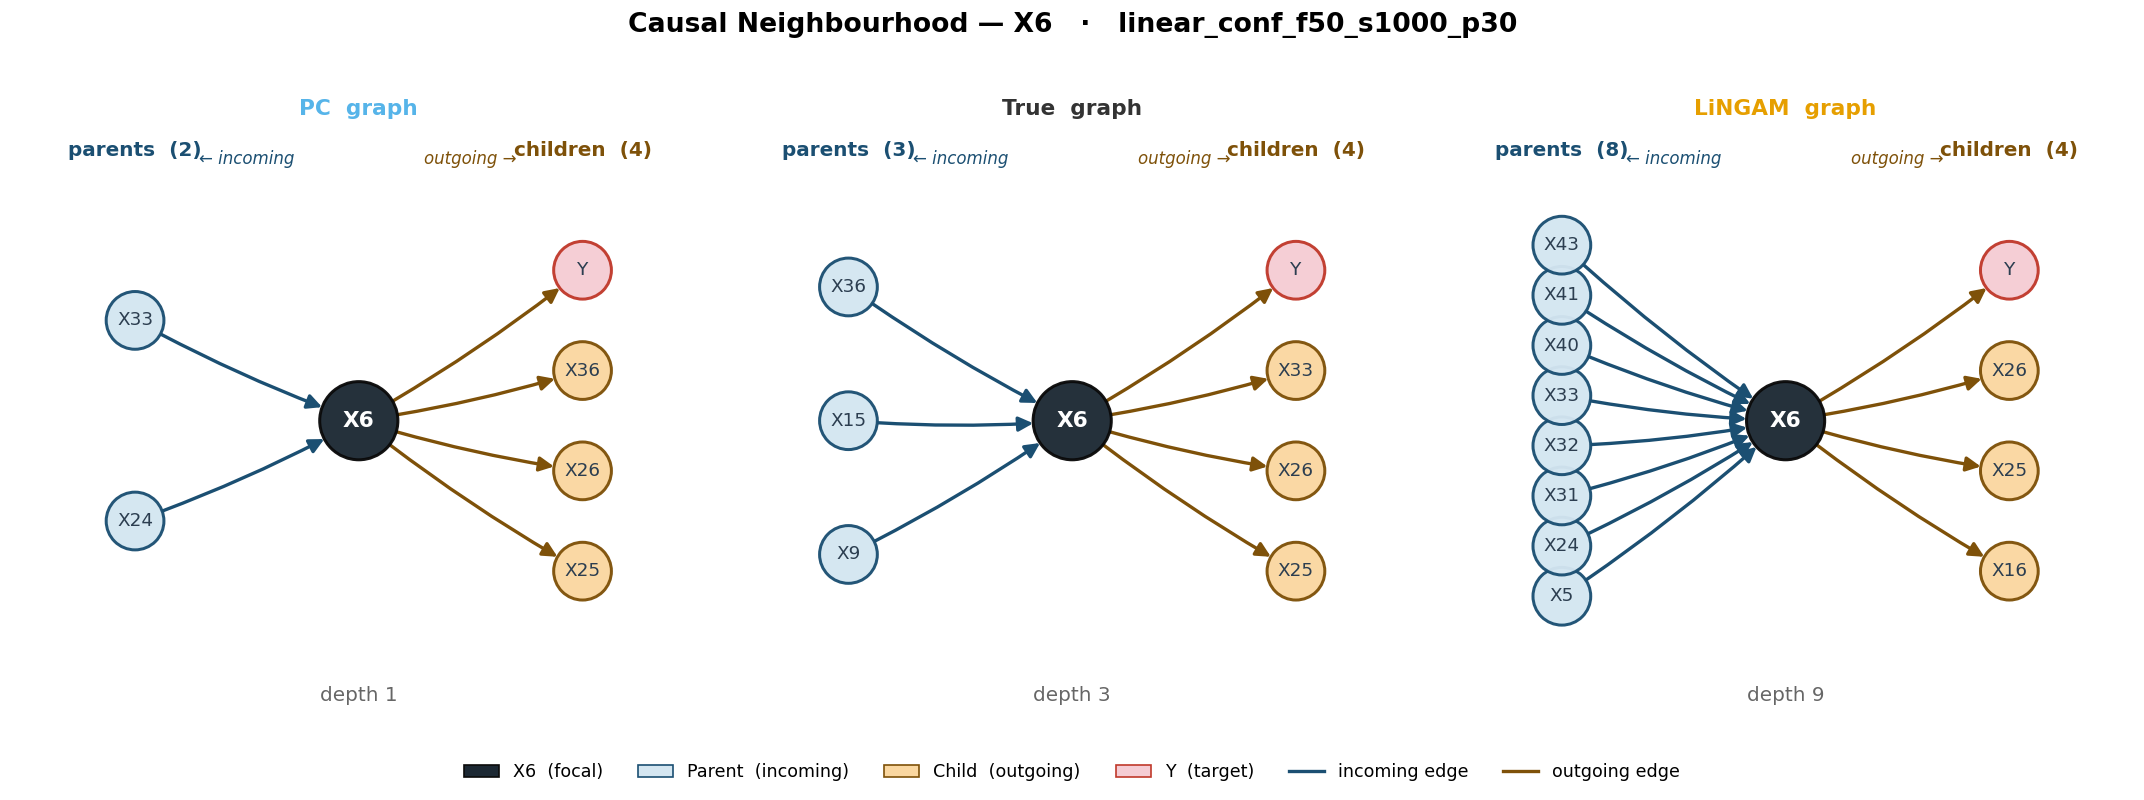

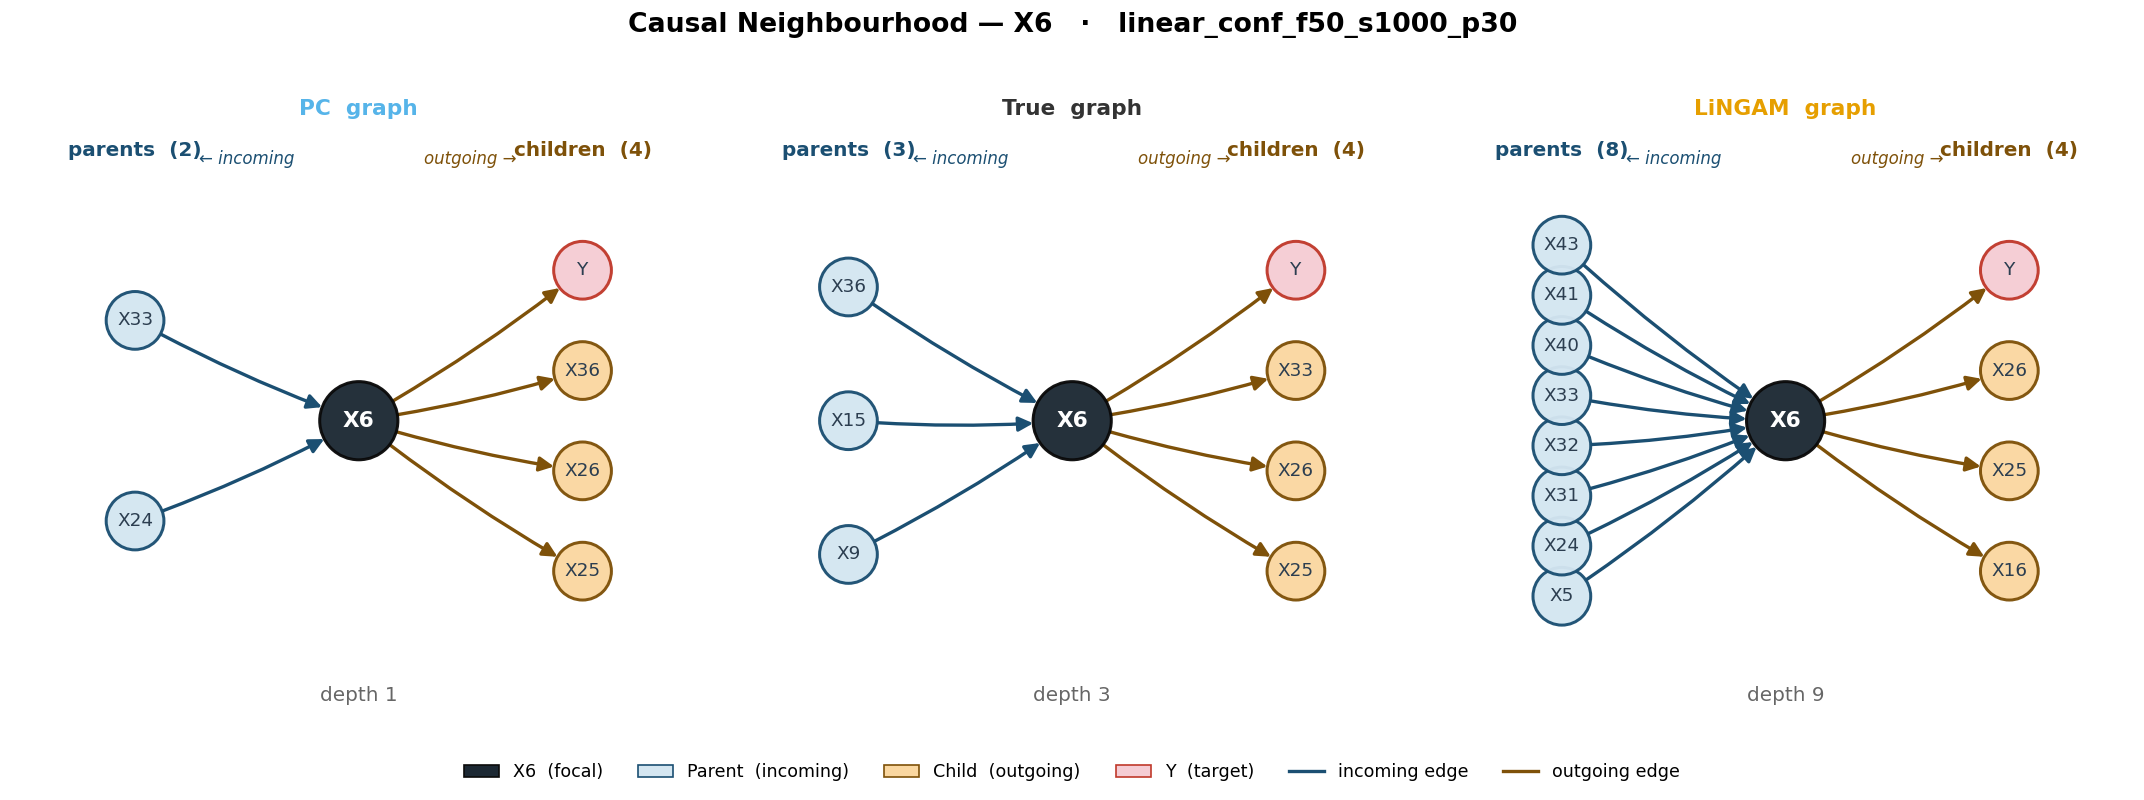

In [37]:
plot_node_neighborhood(
    "X6",
    G_pc,     td_pc,     src_pc,     y_pc,     pc_names,
    G_true,   td_true,   src_true,   y_true,   true_names,
    G_lingam, td_lingam, src_lingam, y_lingam, lingam_names,
    DATASET, save_dir=PLOTS_DIR,
)


### 7.1. SHAP Attribution Comparison: PC vs LiNGAM

Instance-level bar charts and scatter plots comparing Shapley attributions under PC and LiNGAM graphs for the selected features. Columns: Traditional (no graph) | Method (PC) | Method (LiNGAM) | Method (True DAG).

In [39]:
features_names = ["X6"]

In [42]:
fig_scatter_pc_vs_lingam = plot_shap_scatter_pc_vs_lingam(
    shap_data, feature_names, scratch_rank, top_features, x_test,
    pc_edges, lingam_edges, DATASET, N_TOP_FEATURES,
    method= "Causal",
    features=features_names,
    save_dir=PLOTS_DIR,
)

  ✅  Saved → plots/linear_conf_f50_s1000_p30/shap_scatter_causal_X6_linear_conf_f50_s1000_p30.png


In [41]:
# ── Query: one feature ────────────────────────────────────────────────────────
# node_acc_pc / node_acc_lingam are pre-computed in Section 4
get_node_accuracy(
    features_names,
    {"PC": node_acc_pc, "LiNGAM": node_acc_lingam},
)


 graph feature  in_prec  in_rec  in_f1  out_prec  out_rec  out_f1  overall_prec  overall_rec  overall_f1
LiNGAM      X6    0.000   0.000  0.000     0.667    0.667   0.667         0.182        0.333       0.235
    PC      X6    0.000   0.000  0.000     0.667    0.667   0.667         0.400        0.333       0.364


,graph,feature,in_prec,in_rec,in_f1,out_prec,out_rec,out_f1,overall_prec,overall_rec,overall_f1,true_in,pred_in,true_out,pred_out
0,LiNGAM,X6,0.0,0.0,0.0,0.666667,0.666667,0.666667,0.181818,0.333333,0.235294,3,8,3,3
1,PC,X6,0.0,0.0,0.0,0.666667,0.666667,0.666667,0.400000,0.333333,0.363636,3,2,3,3


In [14]:


baseline = "Flow (LiNGAM)"
compared = "Flow (PC)"

# SHAP vs Feature Value
plot_shap_vs_feature(
    shap_data, feature_names, x_test,
    method_1=baseline,
    method_2=compared,
    features=features_names,
    dataset=DATASET,
    save_dir=PLOTS_DIR,
)

# SHAP vs Instance
plot_shap_vs_instance(
    shap_data, feature_names,
    method_1=baseline,
    method_2=compared,
    features=features_names,
    # instance_idx=instance_idx,   # optional — None = all instances
    dataset=DATASET,
    mode="markers",  
    save_dir=PLOTS_DIR, # or "lines+markers"
)

  ✅  Saved → plots/linear_conf_f50_s1000_p30/shap_vs_feature_Flow__LiNGAM__vs_Flow__PC__linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/shap_vs_instance_Flow__LiNGAM__vs_Flow__PC__linear_conf_f50_s1000_p30.png


## 8. True DAG Node Highlight

> The True-graph neighbourhood is now shown as the **centre panel** of the Section 7 figure (`plot_node_neighborhood`).  
> This section is kept as a placeholder for any additional True-graph analysis.

In [15]:
# True-graph neighbourhood is now the centre panel of plot_node_neighborhood (Section 7).
# Uncomment to draw the True DAG standalone if needed:
# plot_dag_highlight_true(
#     G_true, pos_true, td_true, src_true, y_true, ml_true,
#     "X10", true_names, DATASET, save_dir=PLOTS_DIR,

# )

## 9. Graph Sensitivity Analysis

**Goal**: quantify how much the choice of discovered graph (PC vs LiNGAM vs ground truth) changes the attributions produced by each causal Shapley method. This lets us answer the key thesis question:

> *Which method is causally aware but robust to graph quality?*

### Strategy

| Step | Metric | Graph variants | Instances used |
|------|--------|----------------|----------------|
| 9.1 | Load pre-computed Shapley values from pipeline output | All (PC / LiNGAM / True) | All pipeline test instances (~100) |
| 9.2 | **Graph Sensitivity Score (GSS)** — importance-magnitude change between PC and LiNGAM | PC vs LiNGAM | All pre-computed instances |
| 9.3 | **Ranking Robustness** — Spearman ρ, Top-K Jaccard, True-parent Precision@K | PC vs LiNGAM vs True | All pre-computed instances |
| 9.4 | **Sign Stability Score (SSS)** — sign agreement between PC and LiNGAM attributions | PC vs LiNGAM | All pre-computed instances |
| 9.5 | **Recommendation summary** — aggregated score per method | All variants | — |

> **Run Section 3 first** (cells through "Load Shapley Values") to populate `shap_data`, `feature_names`, `x_test`, etc.

### 9.1. Data Check

All data (SHAP values, adjacency matrices, model std) was loaded centrally in **Section 3**. Run the cell below to confirm everything is in scope.


In [16]:
# All data for sections 9–13 was loaded in Section 3:
#   shap_data, subset_shap_data, feature_names / feat_names_10
#   true_adj_xx, pc_train_adj_xx, lingam_train_adj_xx
#   N_TRUE_INSTANCES, _output_std
# No re-loading needed — run Section 3 first if the kernel was restarted.
print("✅  Data loaded in Section 3 — ready for sections 9–13.")
print(f"    Methods: {list(subset_shap_data.keys())}")
print(f"    Features: {len(feature_names)}  |  SHAP instances: {N_TRUE_INSTANCES}")


✅  Data loaded in Section 3 — ready for sections 9–13.
    Methods: ['Asymmetric (PC)', 'Causal (PC)', 'Flow (PC)', 'Asymmetric (LiNGAM)', 'Causal (LiNGAM)', 'Flow (LiNGAM)', 'Asymmetric (True)', 'Causal (True)', 'Flow (True)']
    Features: 50  |  SHAP instances: 100


"""
9.2 — Graph Sensitivity Score (GSS): PC vs LiNGAM

GSS(method, feature) = mean_i ( |φ(PC,i,f)| - |φ(LiNGAM,i,f)| )

No outer absolute, no normalisation — the sign encodes direction:
→ GSS > 0 : PC assigns higher mean absolute importance for this feature.
→ GSS < 0 : LiNGAM assigns higher mean absolute importance for this feature.
→ GSS ≈ 0 : both graphs agree on magnitude for this feature.

**Note:** Metrics already computed in section 4. Using pre-computed `gss_feat` and `feat_delta`.
"""

In [17]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed gss_feat and feat_delta

for meth in BASE_METHODS:
    if meth not in gss_feat:
        continue
    g = gss_feat[meth]
    print(f"{meth}: mean GSS = {np.mean(g):.4f}  "
          f"min GSS = {np.min(g):.4f}  max GSS = {np.max(g):.4f}")

# ── A: Feature-level GSS heatmap ──────────────────────────────────────────────
fig_gss_hmap = plot_gss_heatmap(
    gss_feat, feature_names, BASE_METHODS, DATASET, save_dir=PLOTS_DIR,
)

# ── B: Per-instance magnitude delta box plots (ranked by highest GSS) ─────────
fig_delta = plot_gss_delta_box(
    feat_delta, feature_names, METHOD_COLORS,
    DATASET, N_TOP_FEATURES, save_dir=PLOTS_DIR,
)

# ── C: Method-level GSS summary ───────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean GSS':>10}  {'Median GSS':>11}  {'Max |GSS|':>10}  "
      f"{'Feat |GSS|>0.5':>14}  {'Feat |GSS|>0.1':>14}")
print("─" * 85)
for meth in BASE_METHODS:
    if meth not in gss_feat:
        continue
    g = gss_feat[meth]
    print(f"  {meth:<13}  {np.mean(g):>10.4f}  {np.median(g):>11.4f}  "
          f"{np.max(np.abs(g)):>10.4f}  {(np.abs(g)>0.5).sum():>14d}  {(np.abs(g)>0.1).sum():>14d}")

Asymmetric: mean GSS = 0.0107  min GSS = 0.0008  max GSS = 0.0711
Causal: mean GSS = 0.0715  min GSS = 0.0103  max GSS = 0.2975
Flow: mean GSS = 0.0606  min GSS = 0.0009  max GSS = 0.4528


  ✅  Saved → plots/linear_conf_f50_s1000_p30/gss_heatmap_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/gss_delta_box_linear_conf_f50_s1000_p30.png

Method             Mean GSS   Median GSS   Max |GSS|  Feat |GSS|>0.5  Feat |GSS|>0.1
─────────────────────────────────────────────────────────────────────────────────────
  Asymmetric         0.0107       0.0041      0.0711               0               0
  Causal             0.0715       0.0395      0.2975               0              12
  Flow               0.0606       0.0410      0.4528               0               8


"""
9.4 — Sign Stability Score (SSS): PC vs LiNGAM

SSS(m, f) = mean_i  1[ sign(φ^PC_{i,f}) == sign(φ^LiNGAM_{i,f}) ]
             (instances where either value is exactly 0 are excluded)

**Note:** Metrics already computed in section 4. Using pre-computed `sss_feat`.
"""

In [18]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed sss_feat

for meth, arr in sss_feat.items():
    print(f"{meth}: mean SSS = {np.nanmean(arr):.4f}  "
          f"min SSS = {np.nanmin(arr):.4f}  "
          f"features with SSS<0.5 = {(arr < 0.5).sum()}")

# ── A: Feature-level SSS heatmap ──────────────────────────────────────────────
fig_sign_hmap = plot_sss_heatmap(
    sss_feat, feature_names, BASE_METHODS, DATASET, save_dir=PLOTS_DIR,
)

# ── B: Method-level SSS bar chart ─────────────────────────────────────────────
fig_sign_bar = plot_sss_bar(sss_feat, BASE_METHODS, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR)

# ── C: Numeric summary ────────────────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean SSS':>10}  {'Median SSS':>11}  {'Min SSS':>9}  "
      f"{'SSS<0.5':>8}  {'SSS<0.7':>8}")
print("─" * 68)
for meth in BASE_METHODS:
    if meth not in sss_feat:
        continue
    arr   = sss_feat[meth]
    valid = ~np.isnan(arr)
    print(f"  {meth:<13}  {np.nanmean(arr):>10.4f}  {np.nanmedian(arr):>11.4f}  "
          f"{np.nanmin(arr):>9.4f}  {(arr[valid]<0.5).sum():>8d}  {(arr[valid]<0.7).sum():>8d}")

Asymmetric: mean SSS = 0.9407  min SSS = 0.7200  features with SSS<0.5 = 0
Causal: mean SSS = 0.6206  min SSS = 0.3600  features with SSS<0.5 = 12
Flow: mean SSS = 0.8673  min SSS = 0.4343  features with SSS<0.5 = 1


  ✅  Saved → plots/linear_conf_f50_s1000_p30/sss_heatmap_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/sss_bar_linear_conf_f50_s1000_p30.png

Method             Mean SSS   Median SSS    Min SSS   SSS<0.5   SSS<0.7
────────────────────────────────────────────────────────────────────
  Asymmetric         0.9407       0.9600     0.7200         0         0
  Causal             0.6206       0.5950     0.3600        12        33
  Flow               0.8673       0.9237     0.4343         1         7


## 10. True-Graph Alignment (TGA)

Requires `subset_shap_data` from section 9.1 (run that cell first).

We assess how well each causal Shapley method + discovered graph (PC, LiNGAM) recovers the attributions that would be obtained if the **true causal graph** were known. Two complementary lenses:

- **10.1 Sign Alignment** — does the discovered-graph attribution agree in *sign* with the true-graph attribution?
- **10.2 Magnitude Alignment** — how much does importance magnitude shift relative to the true-graph baseline?

### 10.1. Sign Alignment vs True DAG

Does the discovered graph agree in sign with the true graph?

$$
\text{SignAlign}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}\Bigl[\,\text{sign}(\varphi^{(m,g)}_{i,f}) = \text{sign}(\varphi^{(m,\text{True})}_{i,f})\,\Bigr]
$$

where instances with either value exactly 0 are excluded.

**Note:** Metrics already computed in section 4. Using pre-computed `sign_align`.

In [19]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed sign_align

if sign_align:
    # ── Build df_sa for bar chart ──────────────────────────────────────────
    sa_summary_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_TGA:
            if (meth, g) not in sign_align:
                continue
            arr = sign_align[(meth, g)]
            sa_summary_rows.append(dict(
                Method=meth, Graph=g,
                MeanAlign=float(np.nanmean(arr)),
                label=f"{meth} ({g})",
            ))
    df_sa = pd.DataFrame(sa_summary_rows)

    # ── A: Feature-level sign alignment heatmap ───────────────────────────
    fig_sign_hmap = plot_sign_alignment_heatmap(
        sign_align, BASE_METHODS, DISC_GRAPHS_TGA, feature_names,
        DATASET, N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
    )

    # ── B: Overall sign alignment summary bar ─────────────────────────────
    fig_sign_bar = plot_sign_alignment_bar(
        df_sa, sign_align, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR,
    )

    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean SignAlign':>15}  {'Feat<0.5':>9}")
    print("─" * 55)
    for row in sa_summary_rows:
        arr = sign_align[(row["Method"], row["Graph"])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanAlign']:>15.4f}  {(arr<0.5).sum():>9d}")

  ✅  Saved → plots/linear_conf_f50_s1000_p30/sign_alignment_heatmap_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/sign_alignment_bar_linear_conf_f50_s1000_p30.png

Method         Graph      Mean SignAlign   Feat<0.5
───────────────────────────────────────────────────────
  Asymmetric   PC                 0.9412          0
  Asymmetric   LiNGAM             0.9370          0
  Causal       PC                 0.6840          8
  Causal       LiNGAM             0.6254         13
  Flow         PC                 0.5774         11
  Flow         LiNGAM             0.5509         16


### 10.2. Magnitude True-Graph Alignment

How much does the **importance magnitude** shift when the true graph is replaced by a discovered graph?

$$
\text{TGA}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n}\Bigl(\,|\varphi^{(m,g)}_{i,f}| - |\varphi^{(m,\text{True})}_{i,f}|\,\Bigr)
$$

- **TGA > 0**: the discovered graph assigns *higher* mean importance than the True graph for feature $f$.
- **TGA < 0**: the discovered graph assigns *lower* mean importance than the True graph for feature $f$.
- **TGA ≈ 0**: discovered graph and True graph agree in magnitude for feature $f$.

**Note:** Metrics already computed in section 4. Using pre-computed `tga_data`.

In [20]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed tga_data

if tga_data:
    # ── Build df_tga_sum for bar chart ────────────────────────────────────
    tga_summary_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_TGA:
            if (meth, g) not in tga_data:
                continue
            arr = tga_data[(meth, g)]
            tga_summary_rows.append(dict(
                Method=meth, Graph=g,
                MeanTGA=float(np.mean(arr)),
                label=f"{meth} ({g})",
            ))
    df_tga_sum = pd.DataFrame(tga_summary_rows)

    # ── A: Feature-level TGA heatmap ──────────────────────────────────────
    fig_tga_hmap = plot_tga_heatmap(
        tga_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA,
        DATASET, N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
    )

    # ── B: Overall magnitude TGA summary bar chart ────────────────────────
    fig_tga_bar = plot_tga_bar(df_tga_sum, METHOD_COLORS, DATASET, save_dir=PLOTS_DIR)

    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean TGA':>10}  {'Median TGA':>11}  "
          f"{'Max |TGA|':>10}  {'|TGA|>0.1':>10}")
    print("─" * 72)
    for row in tga_summary_rows:
        arr = tga_data[(row["Method"], row["Graph"])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanTGA']:>10.4f}  {np.median(arr):>11.4f}  "
              f"{np.max(np.abs(arr)):>10.4f}  {(np.abs(arr)>0.1).sum():>10d}")
else:
    print("⚠️  No TGA data computed — check that subset_shap_data has True-graph keys.")

  ✅  Saved → plots/linear_conf_f50_s1000_p30/tga_heatmap_linear_conf_f50_s1000_p30.png


  ✅  Saved → plots/linear_conf_f50_s1000_p30/tga_bar_linear_conf_f50_s1000_p30.png

Method         Graph       Mean TGA   Median TGA   Max |TGA|   |TGA|>0.1
────────────────────────────────────────────────────────────────────────
  Asymmetric   PC            0.0102       0.0039      0.0765           0
  Asymmetric   LiNGAM        0.0079       0.0044      0.0367           0
  Causal       PC            0.0532       0.0350      0.3270           6
  Causal       LiNGAM        0.0757       0.0425      0.2940          13
  Flow         PC            0.0734       0.0525      0.4701          13
  Flow         LiNGAM        0.0806       0.0550      0.4166          12


### 10.3. Sign Alignment vs Traditional Baseline

Does the causal graph agree in sign with the Traditional (Scratch) baseline?

$$
\text{SignAlign}_{\text{Scratch}}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}\Bigl[\,\text{sign}(\varphi^{(m,g)}_{i,f}) = \text{sign}(\varphi^{\text{Scratch}}_{i,f})\,\Bigr]
$$

where instances with either value exactly 0 are excluded.

**Note:** Metrics already computed in section 4. Using pre-computed `sign_align_scratch`.

In [21]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed sign_align_scratch

if sign_align_scratch:
    # ── Build summary data ─────────────────────────────────────────────────
    sa_scratch_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_SCRATCH:
            if (meth, g) not in sign_align_scratch:
                continue
            arr = sign_align_scratch[(meth, g)]
            sa_scratch_rows.append(dict(
                Method=meth, Graph=g,
                MeanAlign=float(np.nanmean(arr)),
            ))
    df_sa_scratch = pd.DataFrame(sa_scratch_rows)
    
    # ── A: Feature-level sign alignment heatmap ───────────────────────────
    sa_keys   = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_SCRATCH 
                 if (m, g) in sign_align_scratch]
    sa_labels = [f"{m} ({g})" for m, g in sa_keys]
    sa_matrix = np.stack([sign_align_scratch[k] for k in sa_keys], axis=1)
    
    # Sort features by worst mean alignment
    feat_order = np.argsort(sa_matrix.mean(axis=1))
    top_n_sa = min(40, len(feature_names))
    top_idx_sa = feat_order[:top_n_sa]
    
    fig_sign_hmap_scratch = go.Figure(go.Heatmap(
        z=sa_matrix[top_idx_sa], x=sa_labels,
        y=[feature_names[i] for i in top_idx_sa],
        colorscale="RdYlGn", zmin=0, zmax=1.0,
        colorbar=dict(
            title=dict(text="Sign Align", font=dict(size=11)),
            tickvals=[0, 0.25, 0.5, 0.75, 1.0],
            ticktext=["0 (opp.)", "0.25", "0.5", "0.75", "1.0"],
        ),
        hovertemplate="<b>%{y}</b> — %{x}<br>Sign Align = %{z:.3f}<extra></extra>",
    ))
    fig_sign_hmap_scratch.update_layout(
        title=dict(
            text=(
                f"Sign Alignment vs Traditional Baseline — {DATASET}<br>"
                f"<sup>Fraction where sign(φ_causal) = sign(φ_Traditional). "
                f"Top {top_n_sa} features by worst alignment. N={N_INSTANCES}</sup>"
            ),
            font=dict(size=13),
        ),
        height=max(420, 18 * top_n_sa + 120), width=760,
        yaxis=dict(tickfont=dict(size=9)),
        xaxis=dict(tickfont=dict(size=9), tickangle=-25),
        margin=dict(l=80, r=80, t=90, b=80),
    )
    fig_sign_hmap_scratch.show()
    
    # ── B: Overall sign alignment bar chart ───────────────────────────────
    fig_sign_bar_scratch = go.Figure()
    for g in DISC_GRAPHS_SCRATCH:
        sub = df_sa_scratch[df_sa_scratch["Graph"] == g]
        for _, row in sub.iterrows():
            fig_sign_bar_scratch.add_trace(go.Bar(
                name=row["Method"], x=[g], y=[row["MeanAlign"]],
                marker_color=METHOD_COLORS.get(row["Method"], "#888888"),
                showlegend=(g == DISC_GRAPHS_SCRATCH[0]),
                hovertemplate=f"<b>{row['Method']} ({g})</b><br>Mean Align=%{{y:.3f}}<extra></extra>",
            ))
    fig_sign_bar_scratch.update_layout(
        title=dict(
            text=(
                f"Overall Sign Alignment vs Traditional — {DATASET}<br>"
                f"<sup>Mean across features. 1.0 = all signs match Traditional baseline</sup>"
            ),
            font=dict(size=13),
        ),
        barmode="group", yaxis=dict(title="Mean Sign Alignment", range=[0, 1.05]),
        height=380, width=600,
        xaxis=dict(title="Graph"),
        margin=dict(t=90, b=80),
    )
    fig_sign_bar_scratch.add_hline(
        y=0.5, line=dict(color="gray", width=1, dash="dot"),
        annotation_text="random (0.5)", annotation_font_size=9
    )
    fig_sign_bar_scratch.show()
    
    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean SignAlign':>15}  {'Feat<0.5':>9}")
    print("─" * 55)
    for row in sa_scratch_rows:
        arr = sign_align_scratch[(row["Method"], row["Graph"])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanAlign']:>15.4f}  {(arr<0.5).sum():>9d}")


Method         Graph      Mean SignAlign   Feat<0.5
───────────────────────────────────────────────────────
  Asymmetric   PC                 0.9492          0
  Asymmetric   LiNGAM             0.9424          0
  Causal       PC                 0.6470          6
  Causal       LiNGAM             0.6608          6
  Flow         PC                 0.6342          4
  Flow         LiNGAM             0.6232          7


### 10.4. Magnitude TGA vs Traditional Baseline

How much does the causal graph shift feature importance magnitudes relative to the Traditional (Scratch) baseline?

$$
\text{TGA}_{\text{Scratch}}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n}\Bigl(\,|\varphi^{(m,g)}_{i,f}| - |\varphi^{\text{Scratch}}_{i,f}|\,\Bigr)
$$

- **TGA > 0**: the causal graph assigns *higher* mean importance than Traditional for feature $f$.
- **TGA < 0**: the causal graph assigns *lower* mean importance than Traditional for feature $f$.
- **TGA ≈ 0**: causal graph and Traditional agree in magnitude for feature $f$.

**Note:** Metrics already computed in section 4. Using pre-computed `tga_data_scratch`.

In [22]:
# ── Metrics already computed in section 4 ─────────────────────────────────────
# Using pre-computed tga_data_scratch

if tga_data_scratch:
    # ── Build summary data ─────────────────────────────────────────────────
    tga_scratch_rows = []
    for meth in BASE_METHODS:
        for g in DISC_GRAPHS_SCRATCH:
            if (meth, g) not in tga_data_scratch:
                continue
            arr = tga_data_scratch[(meth, g)]
            tga_scratch_rows.append(dict(
                Method=meth, Graph=g,
                MeanTGA=float(np.mean(arr)),
            ))
    df_tga_scratch = pd.DataFrame(tga_scratch_rows)
    
    # ── A: Feature-level TGA heatmap ───────────────────────────────────────
    fig_tga_hmap_scratch = plot_tga_heatmap(
        tga_data_scratch, feature_names, BASE_METHODS, DISC_GRAPHS_SCRATCH,
        DATASET, N_TRUE_INSTANCES, save_dir=PLOTS_DIR,
    )
    
    # ── B: Overall TGA bar chart ──────────────────────────────────────────
    fig_tga_bar_scratch = go.Figure()
    for g in DISC_GRAPHS_SCRATCH:
        sub = df_tga_scratch[df_tga_scratch["Graph"] == g]
        for _, row in sub.iterrows():
            fig_tga_bar_scratch.add_trace(go.Bar(
                name=row["Method"], x=[g], y=[row["MeanTGA"]],
                marker_color=METHOD_COLORS.get(row["Method"], "#888888"),
                showlegend=(g == DISC_GRAPHS_SCRATCH[0]),
                hovertemplate=f"<b>{row['Method']} ({g})</b><br>Mean TGA=%{{y:.4f}}<extra></extra>",
            ))
    fig_tga_bar_scratch.update_layout(
        title=dict(
            text=(
                f"Overall Magnitude TGA vs Traditional — {DATASET}<br>"
                f"<sup>Higher = larger magnitude difference from Traditional baseline</sup>"
            ),
            font=dict(size=13),
        ),
        barmode="group", yaxis=dict(title="Mean TGA", range=[0, None]),
        height=380, width=600,
        xaxis=dict(title="Graph"),
        margin=dict(t=90, b=80),
    )
    fig_tga_bar_scratch.show()
    
    # ── Numeric summary ────────────────────────────────────────────────────
    print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean TGA':>10}  {'Median TGA':>11}  "
          f"{'Max TGA':>10}  {'TGA>0.1':>10}")
    print("─" * 72)
    for row in tga_scratch_rows:
        arr = tga_data_scratch[(row["Method"], row["Graph"])]
        print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
              f"{row['MeanTGA']:>10.4f}  {np.median(arr):>11.4f}  "
              f"{np.max(arr):>10.4f}  {(arr>0.1).sum():>10d}")
else:
    print("⚠️  No TGA data computed — check that combined_scratch has Scratch key.")

  ✅  Saved → plots/linear_conf_f50_s1000_p30/tga_heatmap_linear_conf_f50_s1000_p30.png



Method         Graph       Mean TGA   Median TGA     Max TGA     TGA>0.1
────────────────────────────────────────────────────────────────────────
  Asymmetric   PC            0.0068       0.0029      0.0336           0
  Asymmetric   LiNGAM        0.0086       0.0038      0.0469           0
  Causal       PC            0.0639       0.0391      0.2506          11
  Causal       LiNGAM        0.0584       0.0337      0.3280           7
  Flow         PC            0.0662       0.0435      0.3206          13
  Flow         LiNGAM        0.0661       0.0536      0.3246           9


## 11. Feature Importance Export

Exports mean SHAP values, mean absolute SHAP values, and feature importance ranks for all methods to a CSV file for further analysis.

In [23]:
# ── Feature importance CSV export ─────────────────────────────────────────────
# Columns: feature, true_parent, then for each method:
#   <method>_mean_shap     — mean SHAP (signed) across test instances
#   <method>_mean_abs_shap — mean |SHAP| across test instances
#   <method>_rank          — importance rank by mean |SHAP| (1 = highest)

rows_fi = []
for feat_i, feat in enumerate(feature_names):
    row = {
        "feature":     feat,
    }
    for method_key, sv in shap_data.items():
        col = method_key.replace(" ", "_").replace("(", "").replace(")", "")
        row[f"{col}_mean_shap"]     = float(sv.mean(axis=0)[feat_i])
        row[f"{col}_mean_abs_shap"] = float(np.abs(sv).mean(axis=0)[feat_i])
    rows_fi.append(row)

df_fi = pd.DataFrame(rows_fi).set_index("feature")

# Add rank columns (1 = most important) ranked by mean |SHAP|
for col in [c for c in df_fi.columns if c.endswith("_mean_abs_shap")]:
    rank_col = col.replace("_mean_abs_shap", "_rank")
    df_fi[rank_col] = df_fi[col].rank(ascending=False, method="min").astype(int)

# Interleave columns per method: mean_shap / mean_abs_shap / rank
abs_cols  = [c for c in df_fi.columns if c.endswith("_mean_abs_shap")]
shap_cols = [c.replace("_mean_abs_shap", "_mean_shap") for c in abs_cols]
rank_cols = [c.replace("_mean_abs_shap", "_rank")      for c in abs_cols]
ordered   = [c for trio in zip(shap_cols, abs_cols, rank_cols) for c in trio]
df_fi = df_fi[ordered].sort_values(abs_cols[0], ascending=False)  # sorted by Scratch mean |SHAP|

out_path = EXPLAINABILITY_DIR / DATASET / f"feature_importance_{DATASET}.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
df_fi.to_csv(out_path, sep=";", decimal=",")
print(f"Saved → {out_path}")
print(f"Shape  : {df_fi.shape}  ({len(feature_names)} features × {len(abs_cols)} methods × 3 metrics)")
df_fi.head(10)

Saved → /Users/juanrios/Documents/master_thesis/data/explainability/linear_conf_f50_s1000_p30/feature_importance_linear_conf_f50_s1000_p30.csv
Shape  : (50, 30)  (50 features × 10 methods × 3 metrics)


,Scratch_mean_shap,Scratch_mean_abs_shap,Scratch_rank,Asymmetric_PC_mean_shap,Asymmetric_PC_mean_abs_shap,Asymmetric_PC_rank,Causal_PC_mean_shap,Causal_PC_mean_abs_shap,Causal_PC_rank,Flow_PC_mean_shap,...,Flow_LiNGAM_rank,Asymmetric_True_mean_shap,Asymmetric_True_mean_abs_shap,Asymmetric_True_rank,Causal_True_mean_shap,Causal_True_mean_abs_shap,Causal_True_rank,Flow_True_mean_shap,Flow_True_mean_abs_shap,Flow_True_rank
feature,,,,,,,,,,,,,,,,,,,,,
X33,0.190322,1.468332,1,0.167090,1.426587,1,0.200862,1.623989,2,0.511615,...,12,0.189183,1.511678,1,0.014085,0.586354,8,-0.005211,0.347855,16
X24,0.060555,1.408903,2,0.061353,1.396888,2,0.071425,2.191581,1,0.030614,...,1,0.093229,1.384798,2,-0.029959,1.721144,1,-0.065339,0.514257,7
X47,0.015364,1.083066,3,0.002461,1.111062,3,-0.092543,0.522448,8,-0.048388,...,2,0.029099,1.096104,3,-0.092891,0.528351,10,-0.036854,0.361863,14
X46,-0.214361,0.865652,4,-0.203383,0.862635,4,-0.153871,0.409706,13,0.010960,...,3,-0.206456,0.852385,4,-0.146991,0.444724,14,-0.087622,0.547443,5
X7,-0.079934,0.754406,5,-0.026195,0.740788,6,-0.074613,0.330977,16,-0.054778,...,19,-0.118742,0.757804,5,-0.084455,0.443032,15,0.003696,0.123661,32
X41,0.108598,0.748699,6,0.147926,0.786810,5,0.077780,0.304963,17,0.010275,...,9,0.120241,0.748921,6,0.068543,0.304322,20,0.039261,0.201777,22
X48,-0.124363,0.698299,7,-0.119002,0.695143,7,-0.000956,0.289711,19,-0.023810,...,4,-0.107601,0.695564,7,-0.032353,0.317380,19,-0.035649,0.366535,13
X39,0.066408,0.574189,8,0.072345,0.580106,8,0.062889,0.422412,12,0.018638,...,24,0.056590,0.581486,8,0.027737,0.276956,21,0.029615,0.375517,12
X44,0.095856,0.503005,9,0.099319,0.498653,9,0.103131,0.526884,7,0.125998,...,5,0.095417,0.496367,9,0.090223,0.609739,7,0.225934,1.006683,1


## 12. Adjacency Matrix Comparison — True vs PC vs LiNGAM (X-only block)

  ✅  Saved → plots/linear_conf_f50_s1000_p30/adjacency_comparison_linear_conf_f50_s1000_p30.png


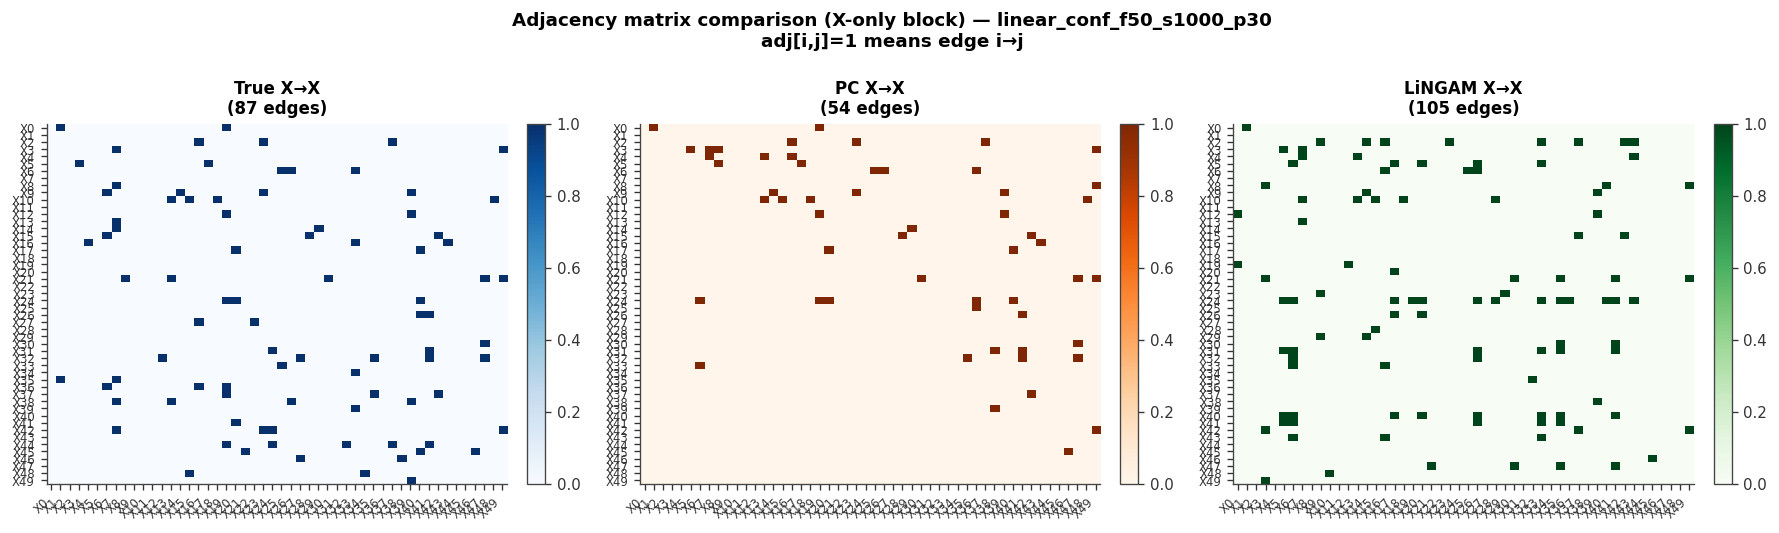

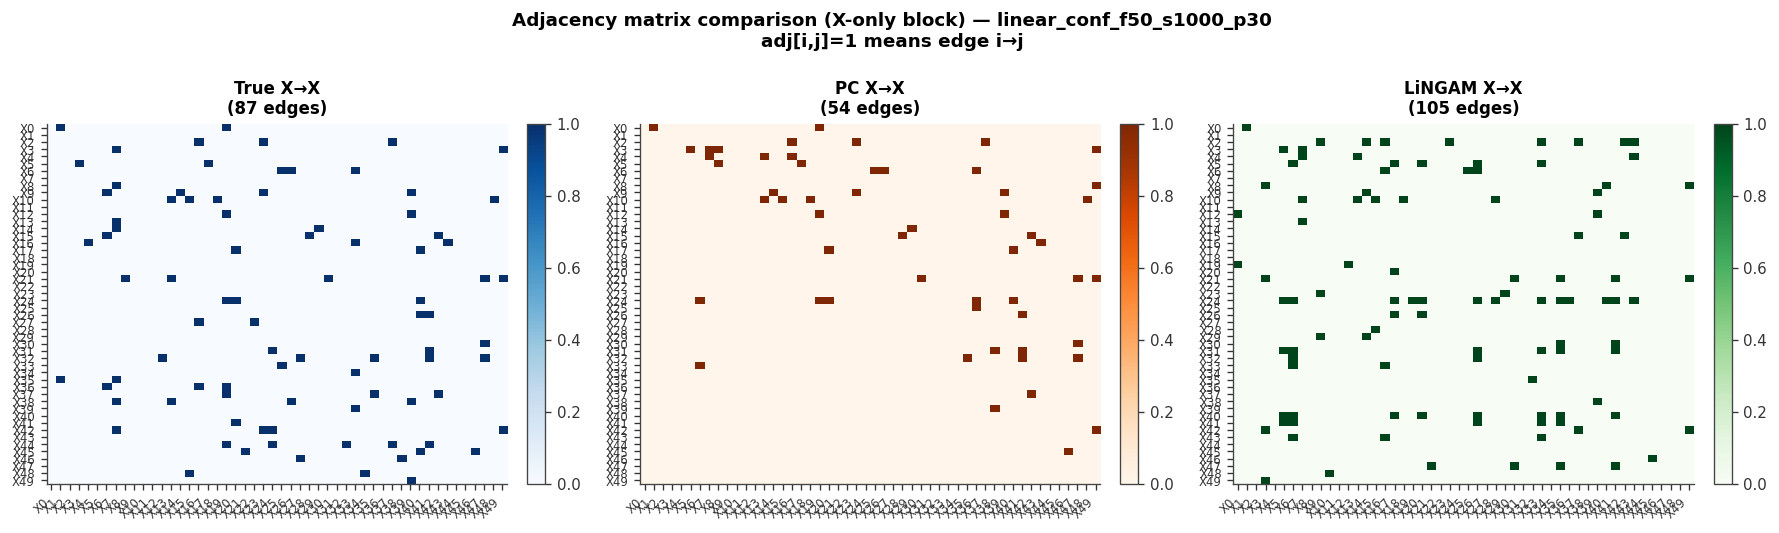

In [24]:
plot_adjacency_comparison(
    true_adj_xx, pc_train_adj_xx, lingam_train_adj_xx,
    feature_names, DATASET, save_dir=PLOTS_DIR,
)
